# Gamma Ray Bursts

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
import sklearn
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

In [3]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

In [4]:
np.random.seed(42)

In [5]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])


In [6]:
print('data shape:', data.shape)
print('headers:',names)

data shape: (15, 8777)
headers: ['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


There are data about Gamma Ray Bursts. I would like to see if GRBs present subclasses.
I will use the following features:
- T90
- fluence
- redshift

In [7]:
data[6].shape

(8777,)

In [8]:
T90=np.array(data[6],dtype=float)
flux=np.array(data[9],dtype=float)
z=np.array(data[11],dtype=float)

## T90

quick visualization using an histogram

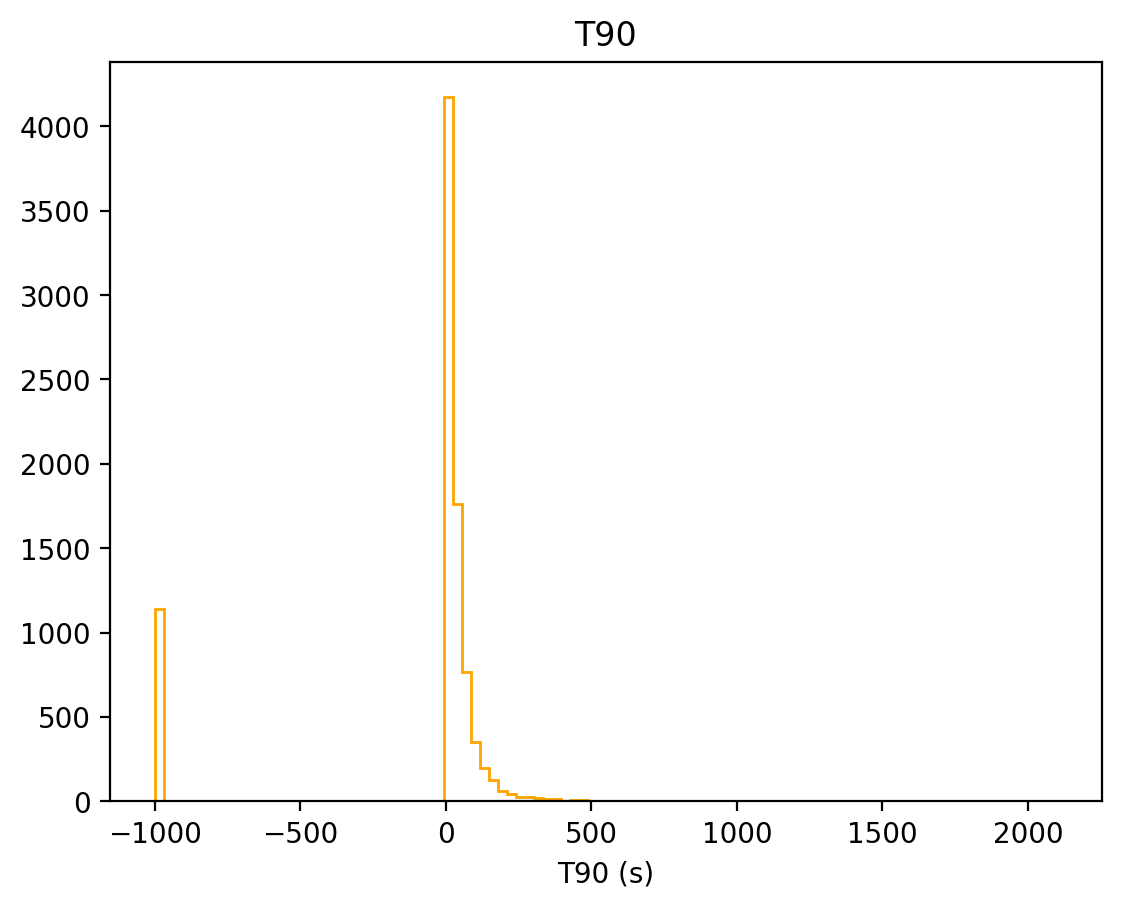

In [9]:
plt.hist(T90, bins=100,histtype='step', color='orange');
plt.title('T90')
plt.xlabel('T90 (s)')
plt.show()

Neglect outliers (missing measurements) just for visualization purposes

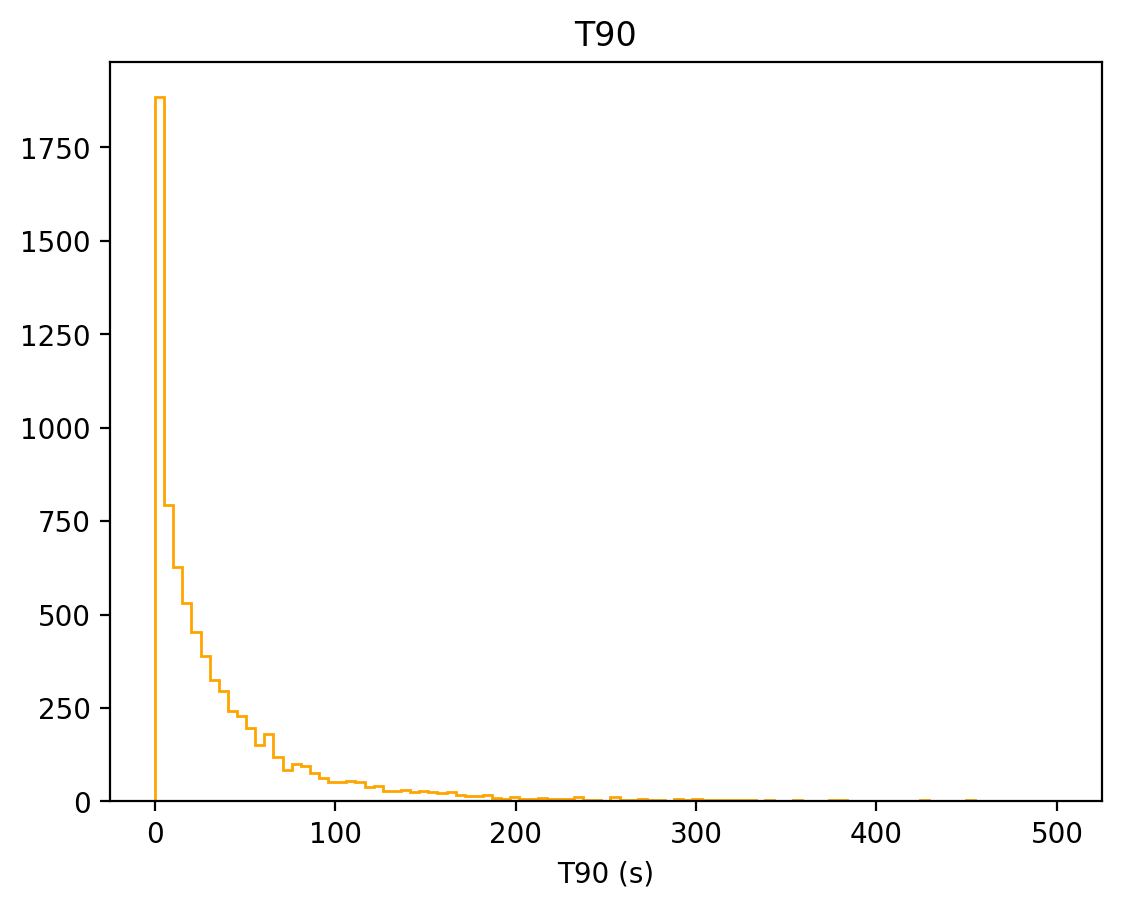

In [10]:
plt.hist(T90, bins=np.linspace(0,500,100),histtype='step', color='orange');
plt.title('T90')
plt.xlabel('T90 (s)')
plt.show()

Plot in log scale 

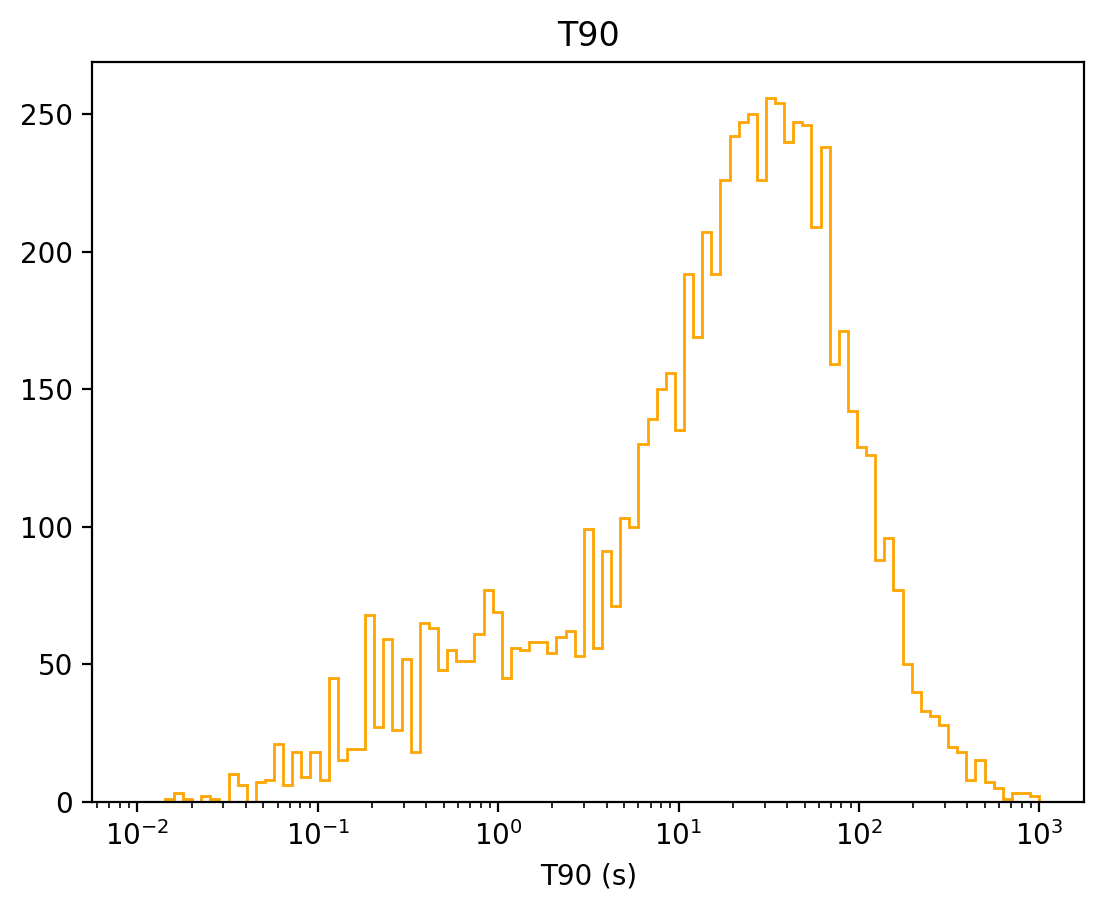

In [11]:
plt.hist(T90, bins=np.logspace(-2,3,100), histtype='step', color='orange');
plt.semilogx()
plt.title('T90')
plt.xlabel('T90 (s)')
plt.show()

There could be two different classes according to T90, just by looking at this histogram

## fluence

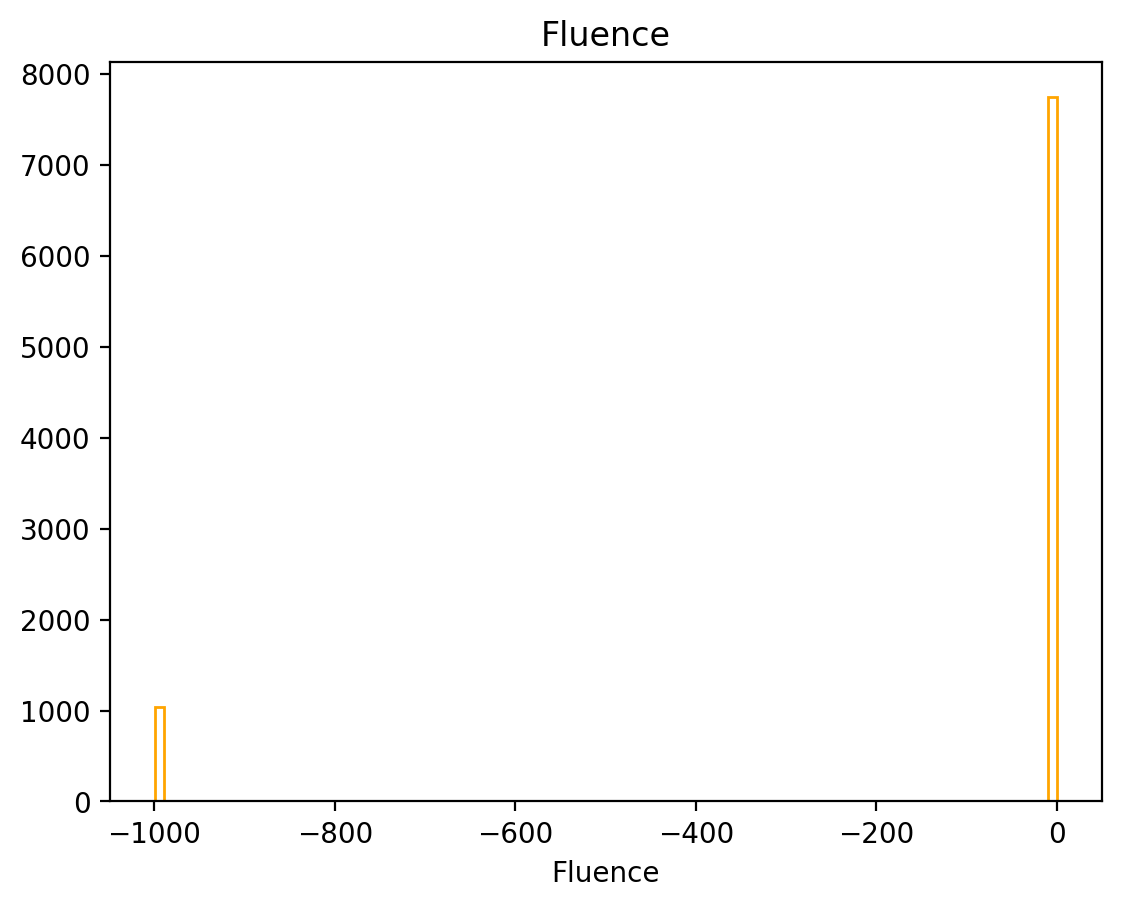

In [12]:
plt.hist(flux, bins=100,histtype='step', color='orange');
plt.title('Fluence')
plt.xlabel('Fluence')
plt.show()

Neglect outliers just for visualization purposes

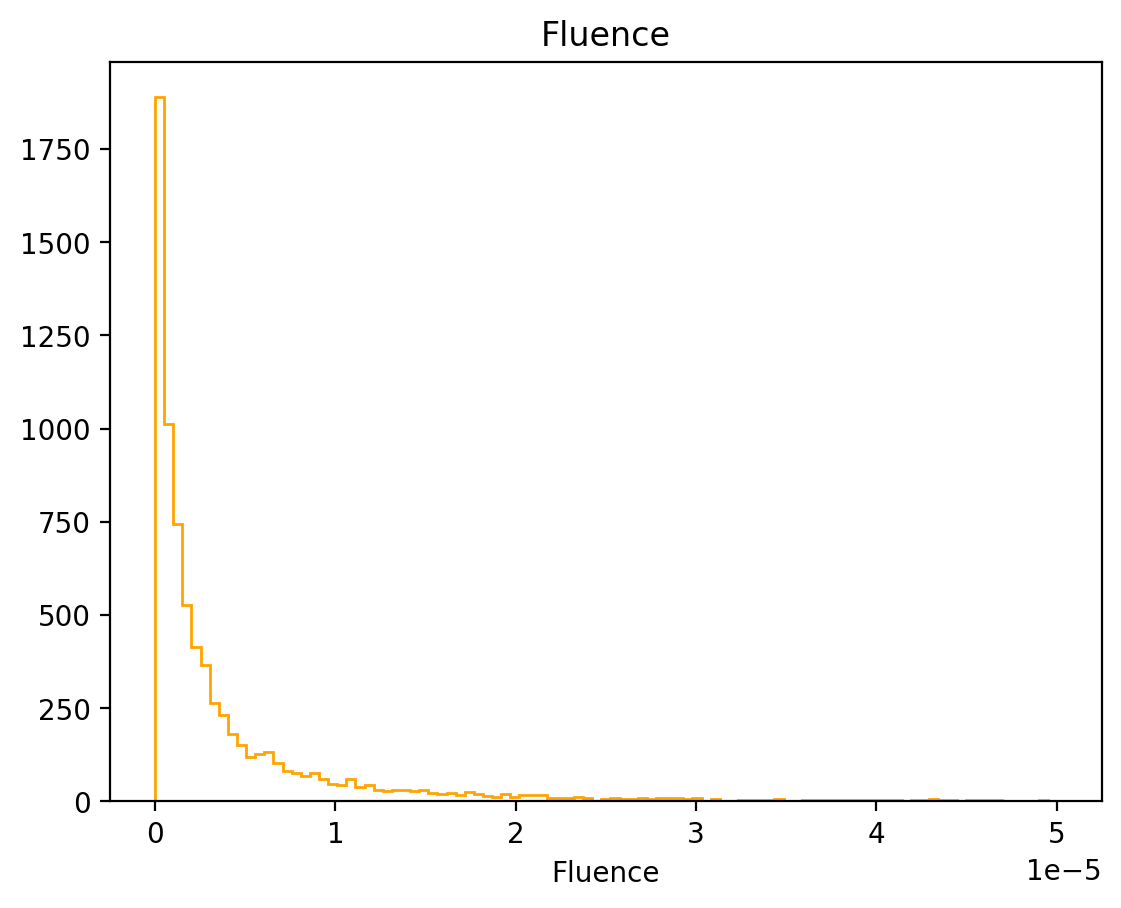

In [13]:
plt.hist(flux, bins=np.linspace(0,5e-5,100),histtype='step', color='orange');
plt.title('Fluence')
plt.xlabel('Fluence')
plt.show()

Plot in log scale

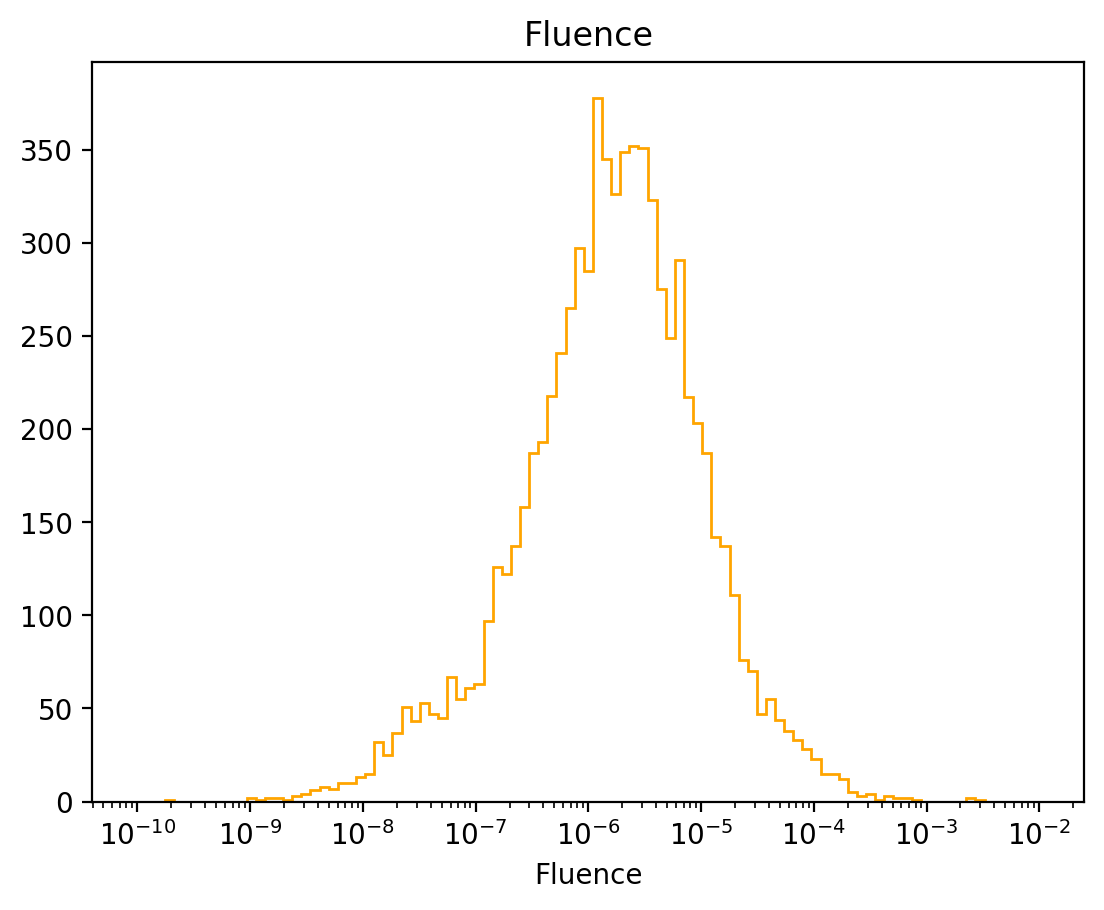

In [14]:
plt.hist(flux, bins=np.logspace(-10,-2,100),histtype='step', color='orange');
plt.title('Fluence')
plt.xlabel('Fluence')
plt.semilogx()
plt.show()

## Redshift

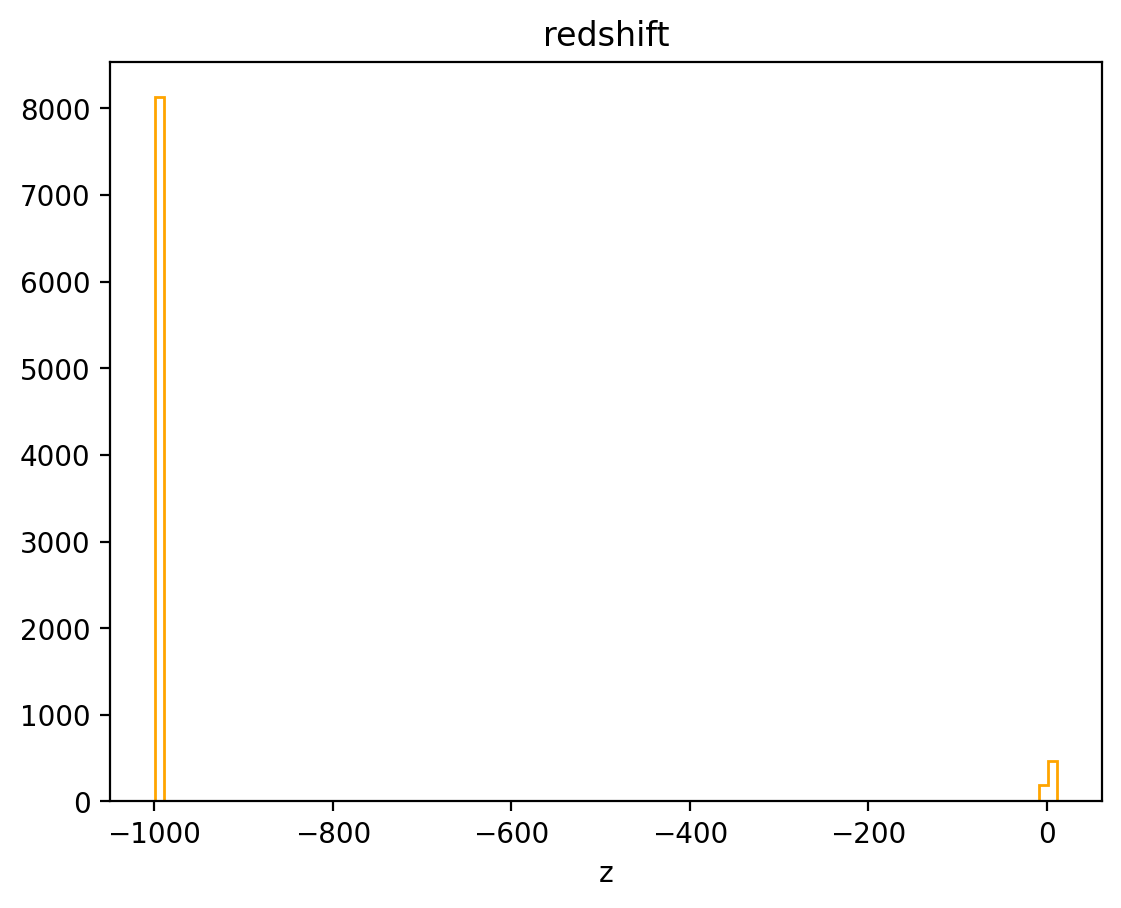

In [15]:
plt.hist(z, bins=100,histtype='step', color='orange');
plt.title('redshift')
plt.xlabel('z')
plt.show()

There are not many redshift measurements 

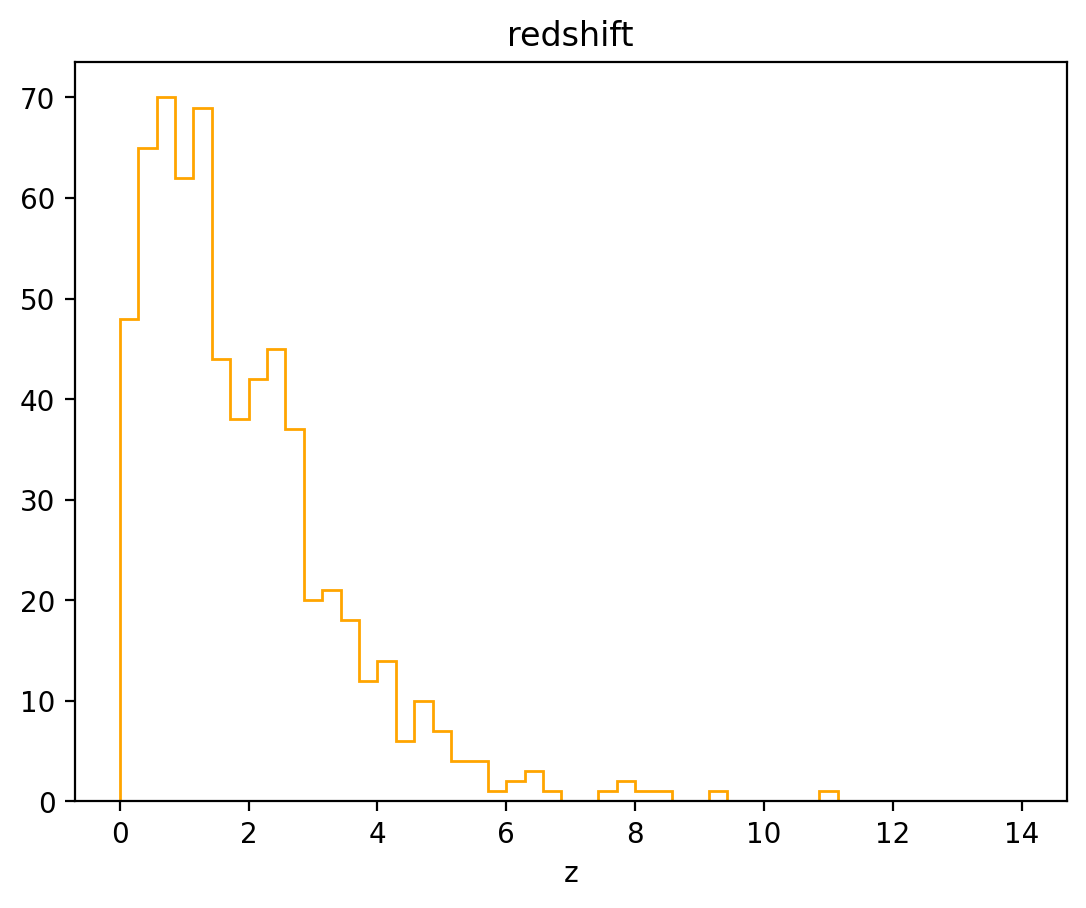

In [16]:
plt.hist(z, bins=np.linspace(0,14,50),histtype='step', color='orange');
plt.title('redshift')
plt.xlabel('z')
plt.show()

## Data cleaning

First I remove GRBs with missing measurements of T90 and fluence. I also compute the log10 of T90 and flux

In [17]:
mask = (T90 > 0) & (flux > 0)

T90 = T90[mask]
flux = flux[mask]
z = z[mask]

log_T90 = np.log10(T90)
log_flux = np.log10(flux)

#remove nan
#mask = ~np.isnan(log_T90) & ~np.isnan(log_flux) & ~np.isnan(z)

# KDE fit 

From my histogram visualizations I assume that T90 could hide a bimodality, so I will try density estimation with KDE to find the pdf of the data

I tried different bandwidth (naive guesses) and 0.2 didn't look bad

In [18]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(log_T90.reshape(-1,1))

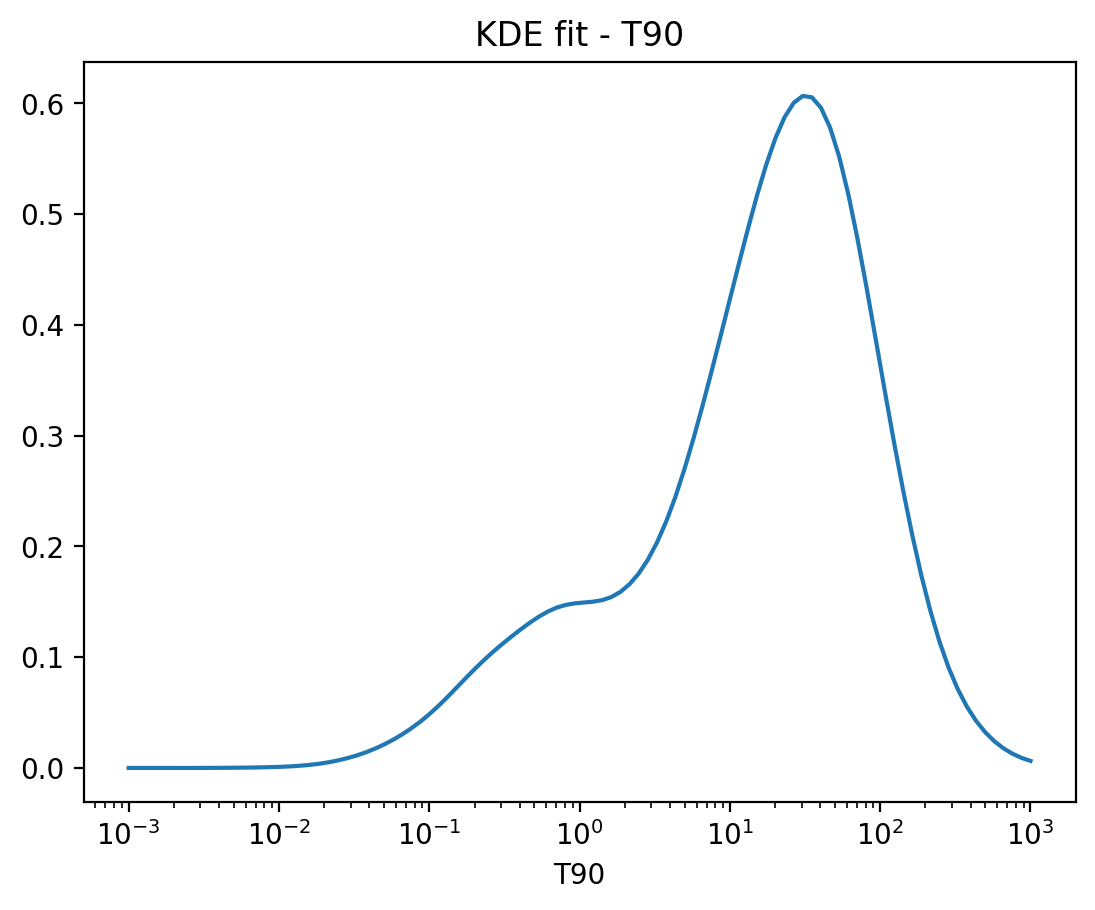

In [48]:
xgrid=np.logspace(-3,3,100)
ygrid = np.exp(kde.score_samples(np.log10(xgrid)[:,np.newaxis]))

plt.plot(xgrid,ygrid)
plt.title('KDE fit - T90')
plt.xlabel('T90')
plt.semilogx();

Now I use KMeans to perform clustering with 2 clusters: one should be short GRBs(lower T90), one should be long GRBs (higher T90)

1D Clustering (only 1 feature: T90) - KMeans

In [20]:
X=log_T90.reshape(-1,1)

kmeans = KMeans(n_clusters=2, n_init='auto') # 2 clusters: short GRB and long GRB
kmeans.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [21]:
#centers of the clusters
centers_k1D = kmeans.cluster_centers_ 
centers_k1D = 10**np.squeeze(centers_k1D)
print('centers:', centers_k1D, '(s)') #in seconds

#output of 1D clustering: labels
labels_k1D = kmeans.predict(X)
print('labels:', labels_k1D)

centers: [33.03677255  0.92105052] (s)
labels: [0 0 0 ... 1 0 1]


The output of clustering tells, for each GRB, which is the corresponding cluster (0 or 1)

In [22]:
if centers_k1D[0]>centers_k1D[1]:
    centers_k1D=centers_k1D[::-1] # Reverse array
    labels_k1D = np.array(~np.array(labels_k1D,dtype='bool'),dtype='int') # Swap 0 <--> 1

In [23]:
print('centers:', centers_k1D, '(s)')
print('labels:', labels_k1D)

centers: [ 0.92105052 33.03677255] (s)
labels: [1 1 1 ... 0 1 0]


I can compute the edge between the two clusters as the mean between the max value of the short GRBs and the min of the long GRBs

In [24]:
edge = 10**( np.mean( [max(X[labels_k1D==0]), min(X[labels_k1D==1]) ]))
print('edge:', edge)

edge: 5.511994194481702


Visualize the edge and the centers of the two clusters over the pdf obtained with KDE

Text(0.5, 0, 'T90')

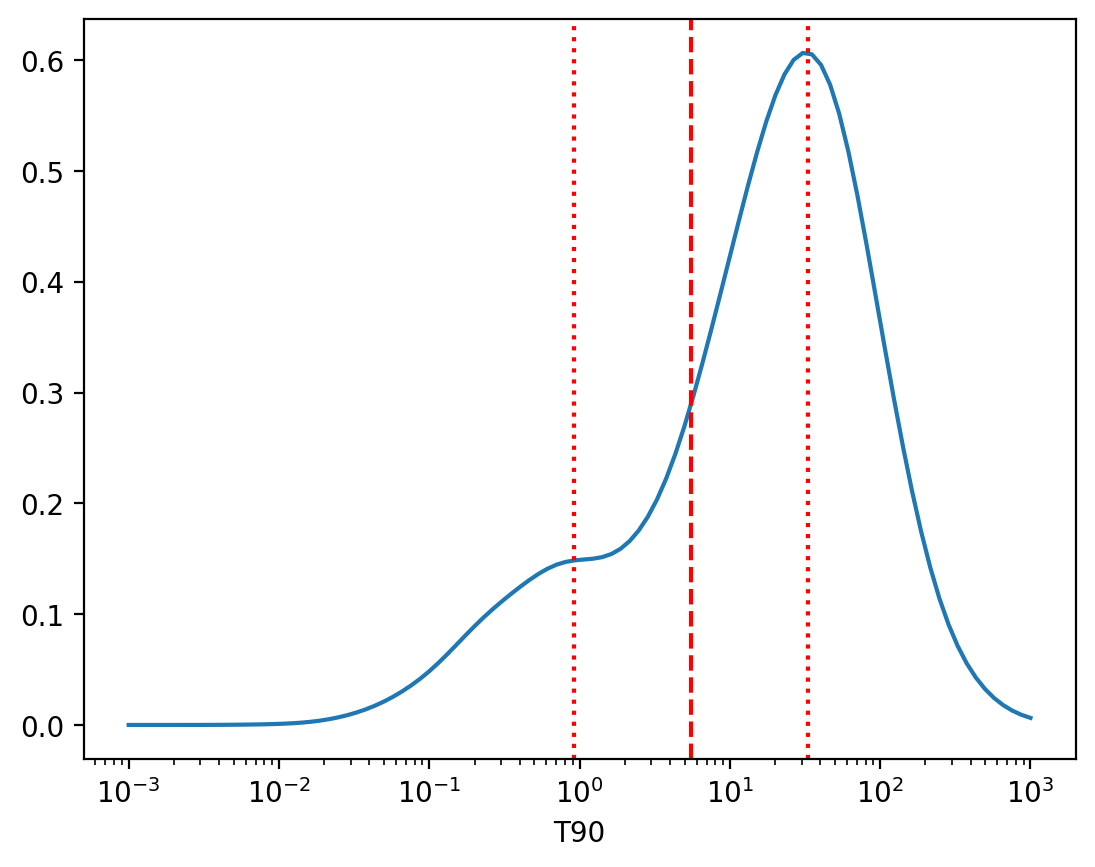

In [25]:
plt.plot(xgrid,ygrid)

for center in centers_k1D:
    plt.axvline(center, c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed')

plt.semilogx();
plt.xlabel('T90')

1D clustering - GaussianMixture model (2 components)

In [26]:
GM = GaussianMixture(2).fit(X)

means = 10**np.squeeze(GM.means_)
print('means:',means)

means: [30.58926406  0.9773212 ]


In [27]:
responsibilities = GM.predict_proba(X)
responsibilities.shape

(7517, 2)

In [28]:
if means[0]>means[1]:
    means=means[::-1]
    responsibilities= responsibilities[:,::-1]

Visualize the output of GaussianMixture for density estimation (pdf of data) and the means

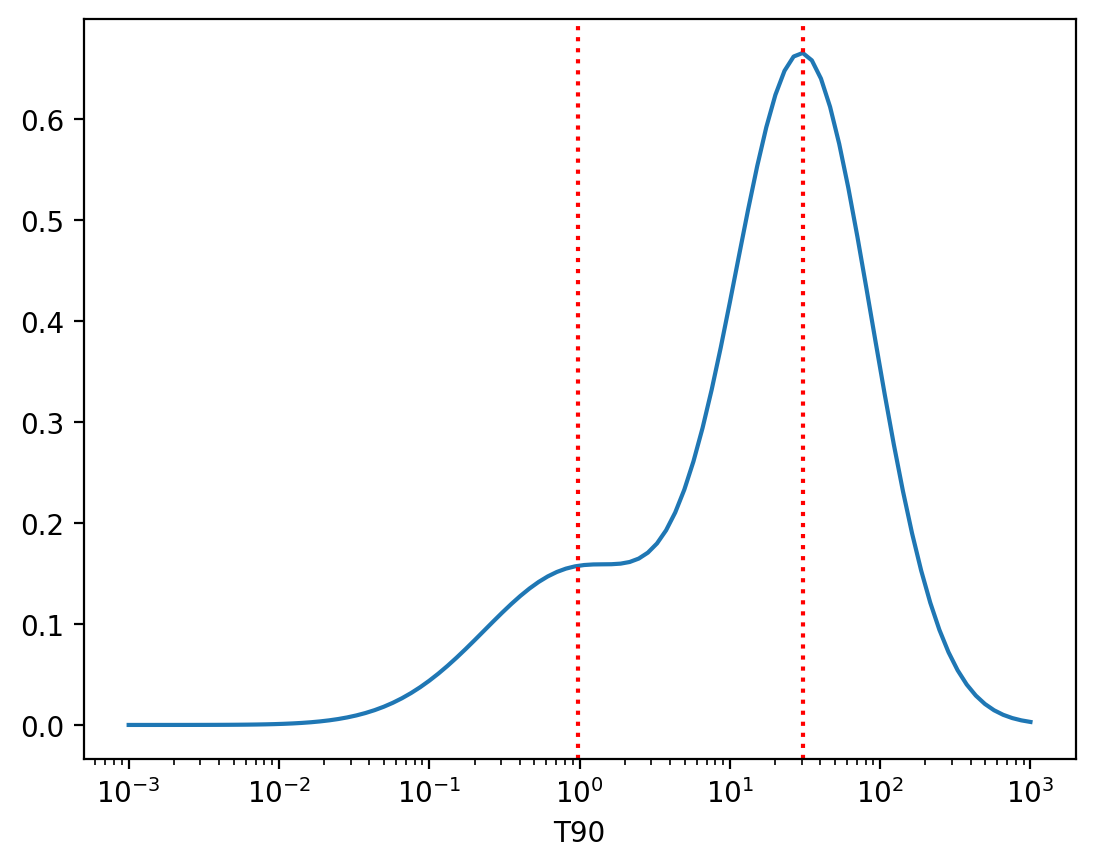

In [29]:
y_GM = np.exp(GM.score_samples( np.log10(xgrid)[:,np.newaxis] ))
plt.plot(xgrid,y_GM)

for mean in means:
    plt.axvline(mean, c='red',ls='dotted')
    
plt.semilogx()
plt.xlabel('T90')
plt.show()

In [30]:
labels_GM = np.array(responsibilities[:,0]<responsibilities[:,1],dtype='int')
print('GaussianMixture labels:', labels_GM)

GaussianMixture labels: [1 1 1 ... 0 1 1]


compare the labels obtained with KMeans and GaussianMixture using a confusion matrix

In [31]:
confusion_matrix(labels_GM,labels_k1D)

array([[1634,    0],
       [ 276, 5607]])

# 2D clustering

Now instead of using T90 only, I will try clustering using both T90 and the fluence

Text(0.5, 1.0, 'T90 vs flux')

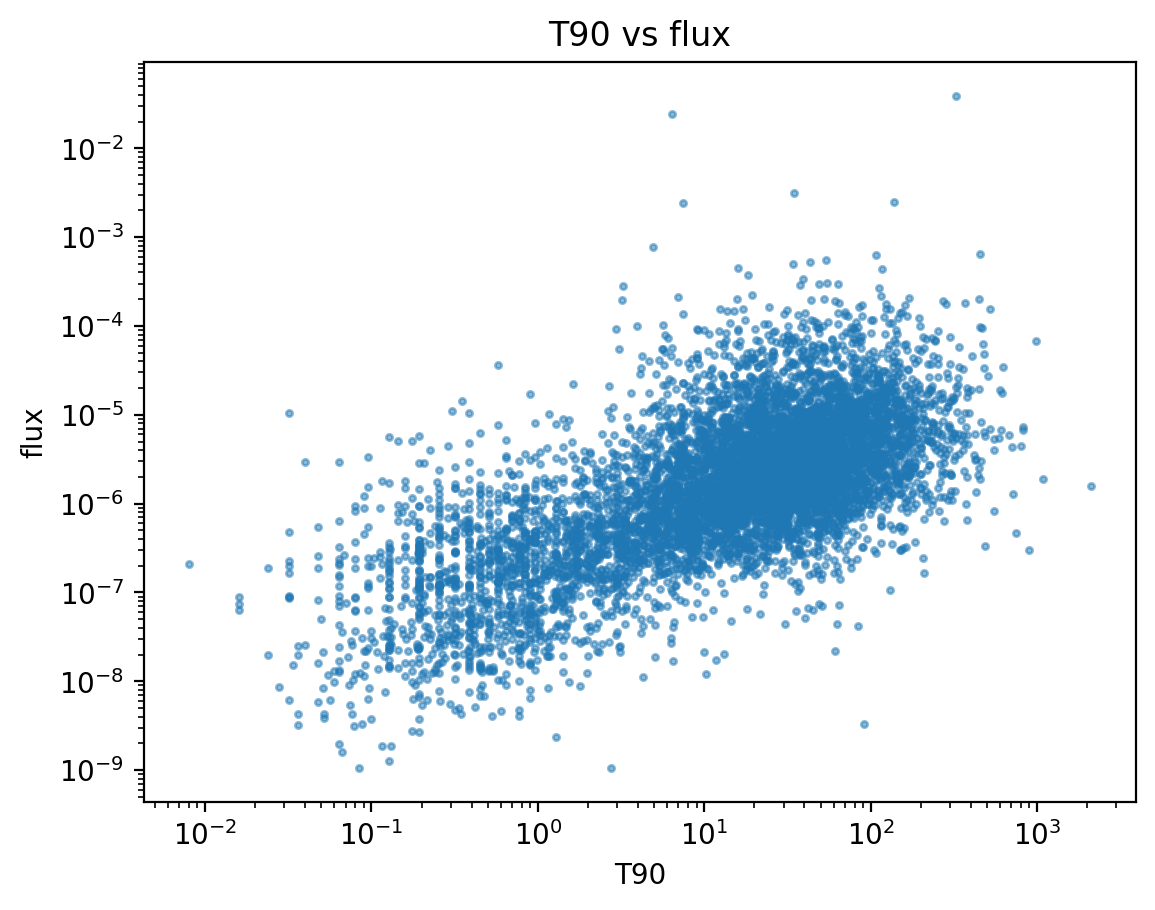

In [32]:
plt.scatter(T90,flux,s=5, alpha=0.5)
plt.loglog()
plt.xlabel('T90')
plt.ylabel('flux')
plt.title('T90 vs flux')

It seems that two clusters are present

Try to visualize the 1D clustering labels on this scatter plot

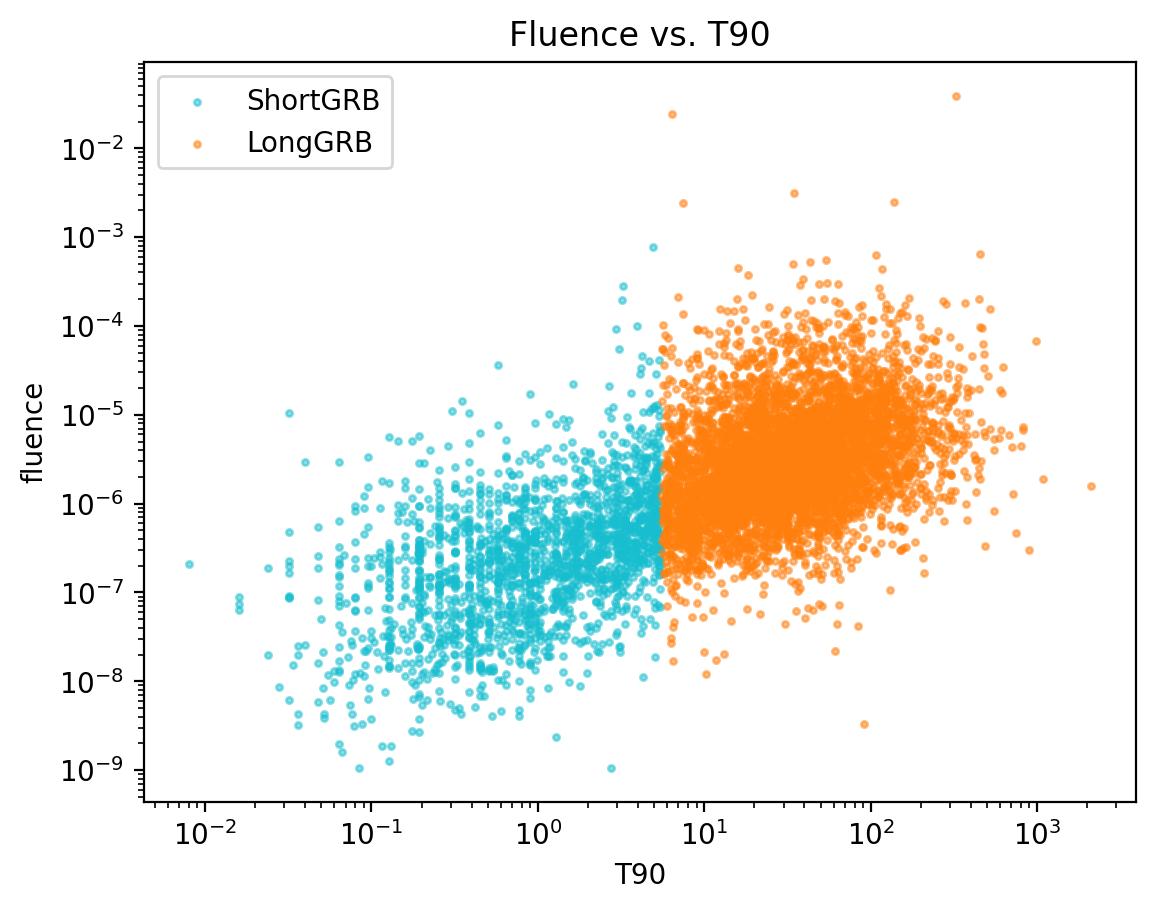

In [33]:
# using labels from 1D clustering

colors = ['C9', 'C1']
labels = ['ShortGRB', 'LongGRB']

for i in range(2):
    plt.scatter(10**log_T90[labels_k1D==i], 10**log_flux[labels_k1D==i], color=colors[i],s=5,alpha=0.5, label=labels[i])

plt.loglog()
plt.title('Fluence vs. T90')
plt.xlabel('T90')
plt.ylabel('fluence')
plt.legend()
plt.show()

2D clustering - KMeans (2 clusters)

In [34]:
X = np.column_stack((log_T90, log_flux))

k_means = KMeans(n_clusters=2,n_init='auto')
k_means.fit(X)

centers_k2D = k_means.cluster_centers_ 
labels_k2D = k_means.predict(X)
print('centers:', centers_k2D)
print('labels:', labels_k2D)

centers: [[ 1.5253335  -5.45405193]
 [ 0.07289159 -6.7150792 ]]
labels: [0 0 0 ... 1 0 0]


In [35]:
if centers_k2D[0,0] > centers_k2D[1,0]:
    centers_k2D = centers_k2D[::-1]        # Reverse array
    labels_k2D = 1 - np.array(labels_k2D)  # Swap 0 <--> 1
print('centers:', centers_k2D, '(s)')
print('labels:', labels_k2D)

centers: [[ 0.07289159 -6.7150792 ]
 [ 1.5253335  -5.45405193]] (s)
labels: [1 1 1 ... 0 1 1]


Visualize the result of 2D clustering: labels and centers

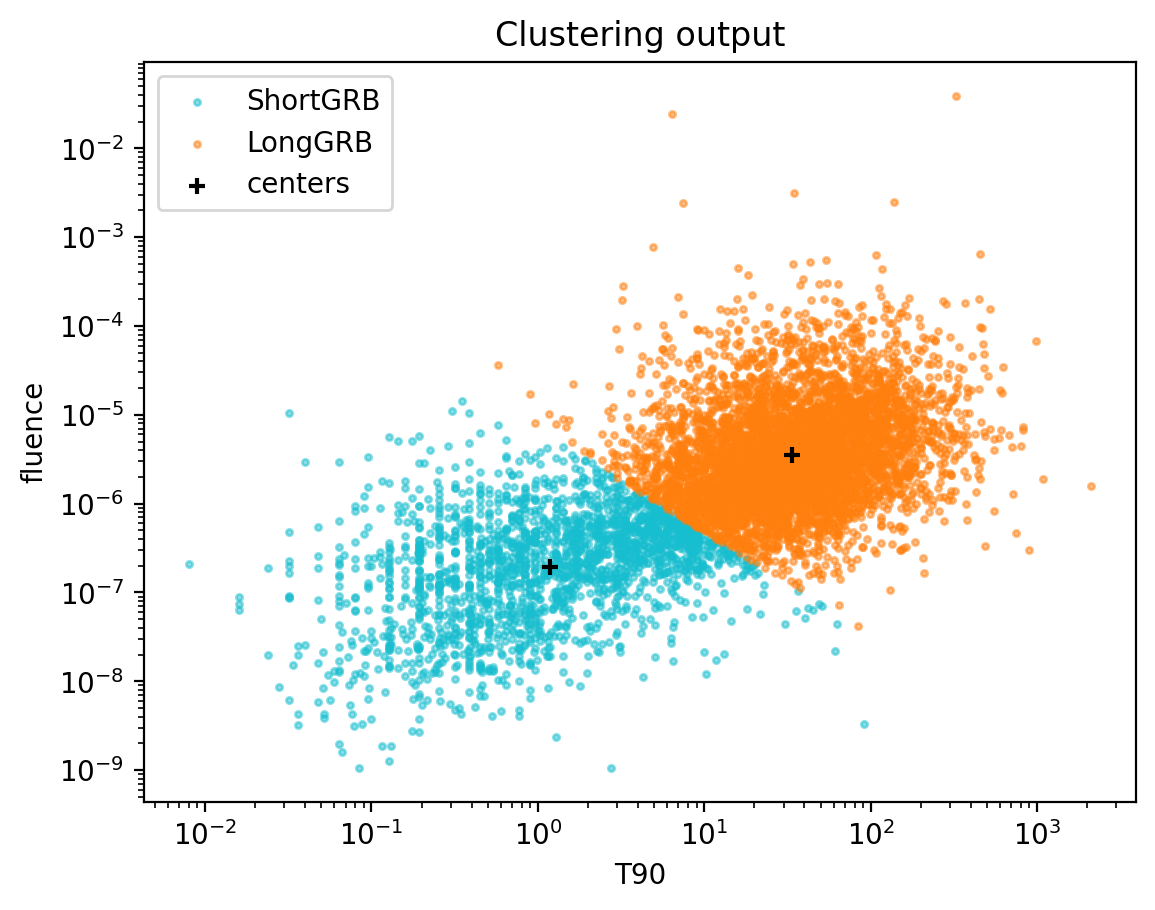

In [36]:
#output of 2D clustering
for i in range(2):
    plt.scatter(10**X[:,0][labels_k2D==i], 10**X[:,1][labels_k2D==i], color=colors[i],s=5,alpha=0.5, label=labels[i])

plt.loglog()
plt.scatter(10**centers_k2D[:,0],10**centers_k2D[:,1], marker='+', c='black', label='centers')
plt.title('Clustering output')
plt.xlabel('T90')
plt.ylabel('fluence')
plt.legend()
plt.show()

Just by looking at this we can say that the outputs are different

2D clustering - time vs redshift (just visualizing the result of 1DKMeans and 2DKMeans clusterings)

(-1.0, 12.0)

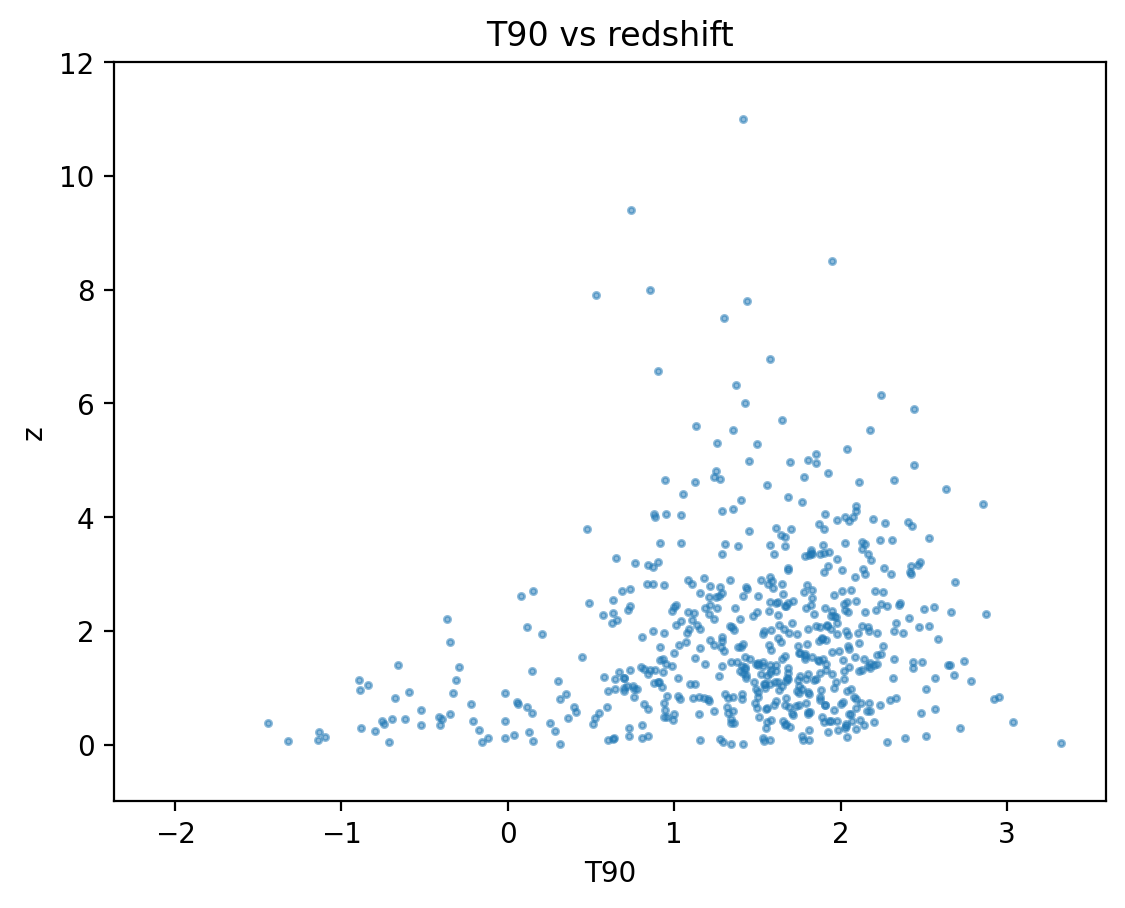

In [37]:
plt.scatter(log_T90,z,s=5, alpha=0.5)
#plt.semilogx()
plt.xlabel('T90')
plt.ylabel('z')
plt.title('T90 vs redshift')
plt.ylim(-1,12)

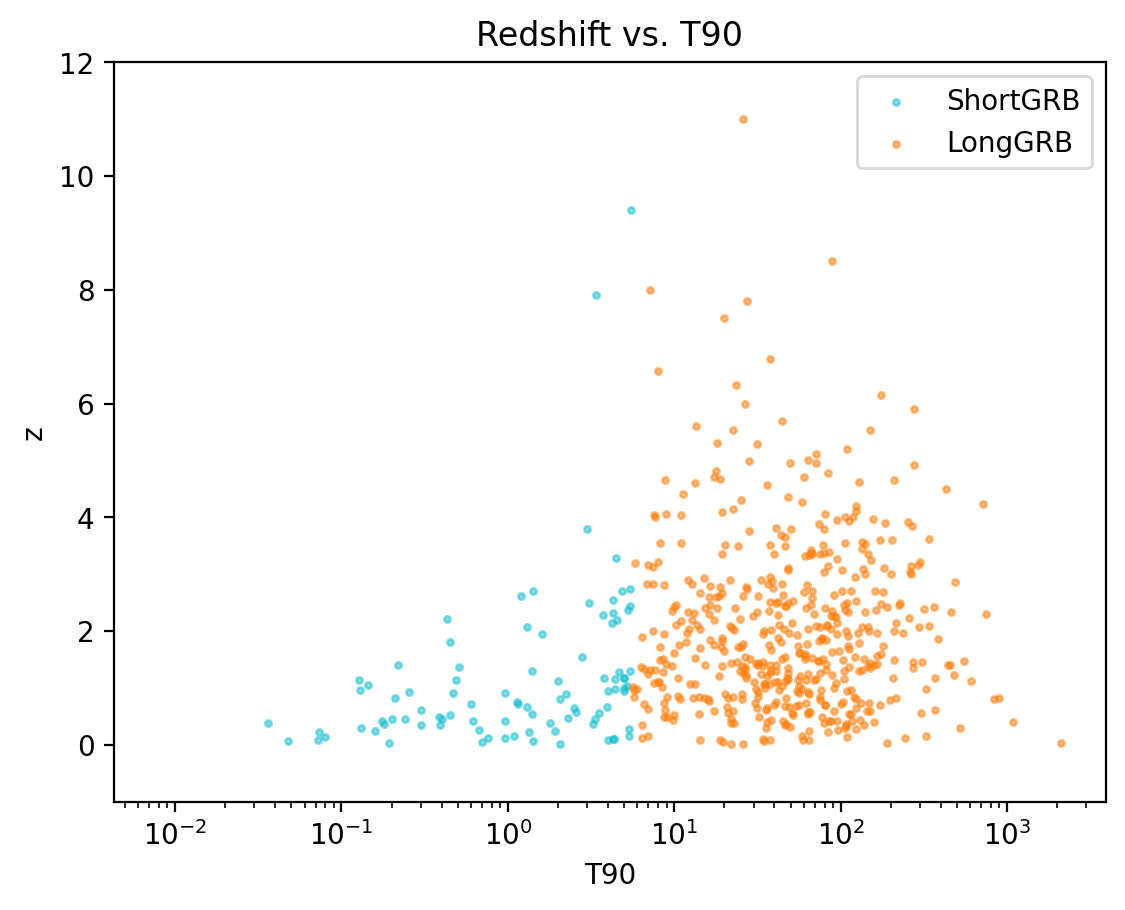

In [38]:
# using labels from 1D clustering
for i in range(2):
    plt.scatter(10**log_T90[labels_k1D==i], z[labels_k1D==i], color=colors[i],s=5,alpha=0.5, label=labels[i])

plt.semilogx()
plt.title('Redshift vs. T90')
plt.xlabel('T90')
plt.ylabel('z')
plt.ylim(-1,12)
plt.legend()
plt.show()

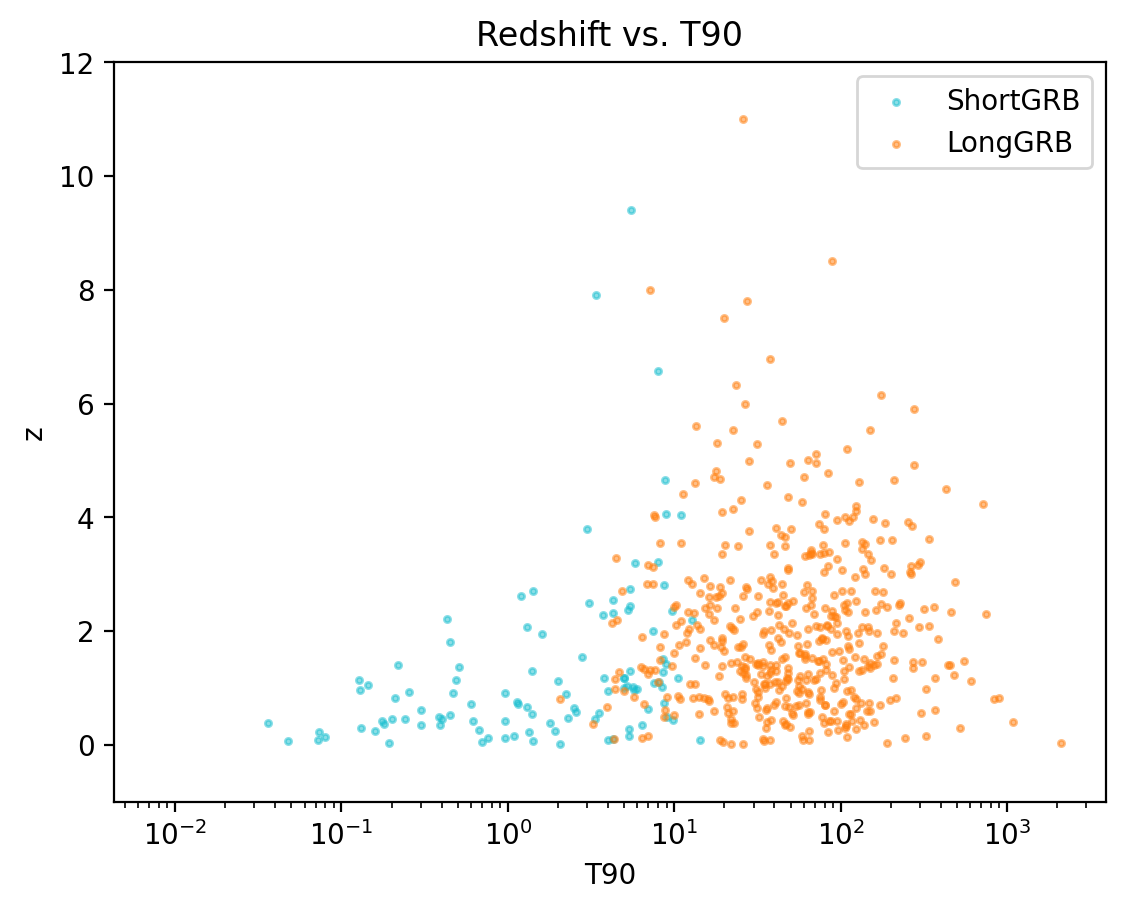

In [39]:
# using labels from 2D clustering
for i in range(2):
    plt.scatter(10**log_T90[labels_k2D==i], z[labels_k2D==i], color=colors[i],s=5,alpha=0.5, label=labels[i])

plt.semilogx()
plt.title('Redshift vs. T90')
plt.xlabel('T90')
plt.ylabel('z')
plt.ylim(-1,12)
plt.legend()
plt.show()

Use a confusion matrix

In [40]:
conf_matrix = confusion_matrix(labels_k1D, labels_k2D)
print(f"Confusion matrix for 1D and 2D clustering:\n{conf_matrix}")

Confusion matrix for 1D and 2D clustering:
[[1752  158]
 [ 314 5293]]
